### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:

ingreso_tienda1 = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

import pandas as pd

resumen_ingresos = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Ingreso Total": [
        ingreso_tienda1,
        ingreso_tienda2,
        ingreso_tienda3,
        ingreso_tienda4
    ]
})

resumen_ingresos["Ingreso Total"] = resumen_ingresos["Ingreso Total"].map("${:,.2f}".format)

resumen_ingresos

,Tienda,Ingreso Total
0,Tienda 1,"$1,150,880,400.00"
1,Tienda 2,"$1,116,343,500.00"
2,Tienda 3,"$1,098,019,600.00"
3,Tienda 4,"$1,038,375,700.00"


# 2. Ventas por categoría

In [3]:

ventas_categoria_t1 = tienda["Categoría del Producto"].value_counts()
ventas_categoria_t2 = tienda2["Categoría del Producto"].value_counts()
ventas_categoria_t3 = tienda3["Categoría del Producto"].value_counts()
ventas_categoria_t4 = tienda4["Categoría del Producto"].value_counts()

resumen_categorias = pd.DataFrame({
    "Tienda 1": ventas_categoria_t1,
    "Tienda 2": ventas_categoria_t2,
    "Tienda 3": ventas_categoria_t3,
    "Tienda 4": ventas_categoria_t4
})

resumen_categorias = resumen_categorias.fillna(0).astype(int)

resumen_categorias["Total"] = resumen_categorias.sum(axis=1)

resumen_categorias = resumen_categorias.sort_values(by="Total", ascending=False)

resumen_categorias

,Tienda 1,Tienda 2,Tienda 3,Tienda 4,Total
Categoría del Producto,,,,,
Muebles,465,442,499,480,1886
Electrónicos,448,422,451,451,1772
Juguetes,324,313,315,338,1290
Electrodomésticos,312,305,278,254,1149
Deportes y diversión,284,275,277,277,1113
Instrumentos musicales,182,224,177,170,753
Libros,173,197,185,187,742
Artículos para el hogar,171,181,177,201,730


# 3. Calificación promedio de la tienda


In [4]:

calif_t1 = tienda["Calificación"].mean()
calif_t2 = tienda2["Calificación"].mean()
calif_t3 = tienda3["Calificación"].mean()
calif_t4 = tienda4["Calificación"].mean()

resumen_calificaciones = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Calificación Promedio": [calif_t1, calif_t2, calif_t3, calif_t4]
})

resumen_calificaciones["Calificación Promedio"] = resumen_calificaciones["Calificación Promedio"].round(2)

resumen_calificaciones = resumen_calificaciones.sort_values(
    by="Calificación Promedio", ascending=False
)

resumen_calificaciones

,Tienda,Calificación Promedio
2,Tienda 3,4.05
1,Tienda 2,4.04
3,Tienda 4,4.00
0,Tienda 1,3.98


# 4. Productos más y menos vendidos

In [5]:
tiendas = [tienda, tienda2, tienda3, tienda4]

resultados = []

for i, t in enumerate(tiendas, start=1):

    productos = t["Producto"].value_counts()

    mas_vendido = productos.idxmax()
    cant_mas = productos.max()

    menos_vendido = productos.idxmin()
    cant_menos = productos.min()

    resultados.append({
        "Tienda": f"Tienda {i}",
        "Producto más vendido": mas_vendido,
        "Cantidad más vendida": cant_mas,
        "Producto menos vendido": menos_vendido,
        "Cantidad menos vendida": cant_menos
    })

resumen_productos = pd.DataFrame(resultados)

resumen_productos

,Tienda,Producto más vendido,Cantidad más vendida,Producto menos vendido,Cantidad menos vendida
0,Tienda 1,Microondas,60,Auriculares con micrófono,33
1,Tienda 2,Iniciando en programación,65,Juego de mesa,32
2,Tienda 3,Kit de bancas,57,Bloques de construcción,35
3,Tienda 4,Cama box,62,Guitarra eléctrica,33


# 5. Envío promedio por tienda

In [6]:

envio_t1 = tienda["Costo de envío"].mean()
envio_t2 = tienda2["Costo de envío"].mean()
envio_t3 = tienda3["Costo de envío"].mean()
envio_t4 = tienda4["Costo de envío"].mean()

resumen_envios = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Costo de envío promedio": [envio_t1, envio_t2, envio_t3, envio_t4]
})

resumen_envios["Costo de envío promedio"] = resumen_envios["Costo de envío promedio"].round(2)

resumen_envios = resumen_envios.sort_values(
    by="Costo de envío promedio",
    ascending=False
)

resumen_envios["Costo de envío promedio"] = resumen_envios["Costo de envío promedio"].map("${:,.2f}".format)

resumen_envios

,Tienda,Costo de envío promedio
0,Tienda 1,"$26,018.61"
1,Tienda 2,"$25,216.24"
2,Tienda 3,"$24,805.68"
3,Tienda 4,"$23,459.46"


# **Gráficos**

In [7]:
import matplotlib.pyplot as plt

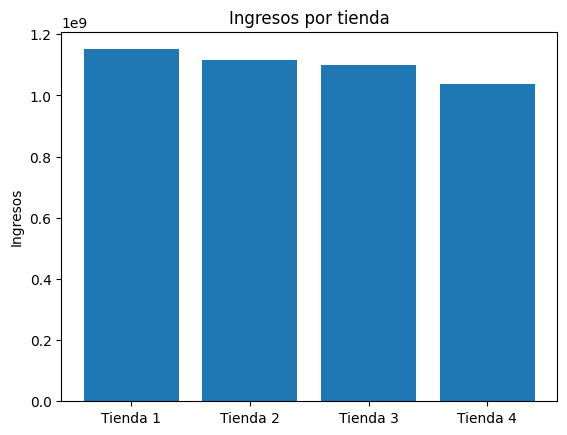

In [8]:
ingresos = [
    tienda["Precio"].sum(),
    tienda2["Precio"].sum(),
    tienda3["Precio"].sum(),
    tienda4["Precio"].sum()
]

tiendas = ["Tienda 1","Tienda 2","Tienda 3","Tienda 4"]

plt.bar(tiendas, ingresos)
plt.title("Ingresos por tienda")
plt.ylabel("Ingresos")
plt.show()

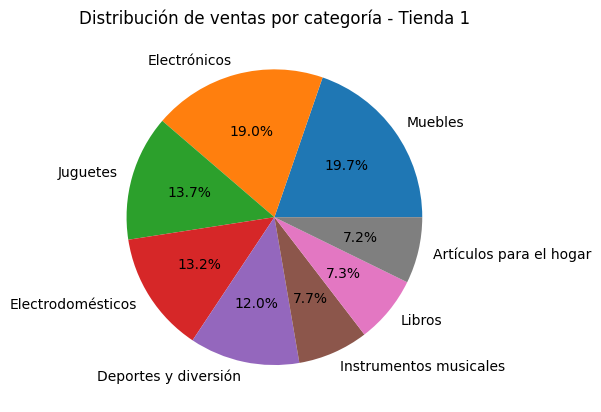

In [9]:
categorias = tienda["Categoría del Producto"].value_counts()

plt.pie(
    categorias,
    labels=categorias.index,
    autopct='%1.1f%%'
)

plt.title("Distribución de ventas por categoría - Tienda 1")

plt.show()

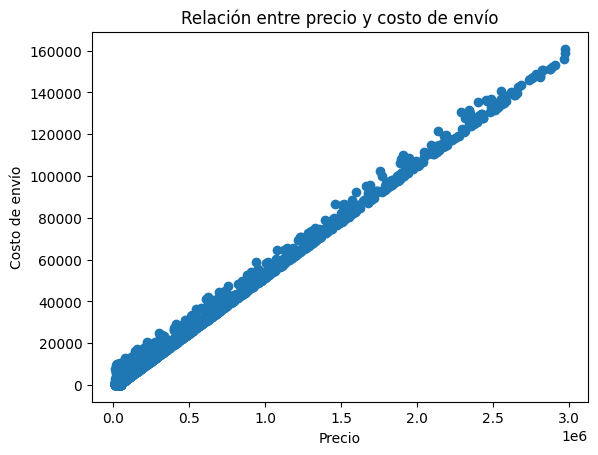

In [10]:
plt.scatter(
    tienda["Precio"],
    tienda["Costo de envío"]
)

plt.title("Relación entre precio y costo de envío")
plt.xlabel("Precio")
plt.ylabel("Costo de envío")

plt.show()

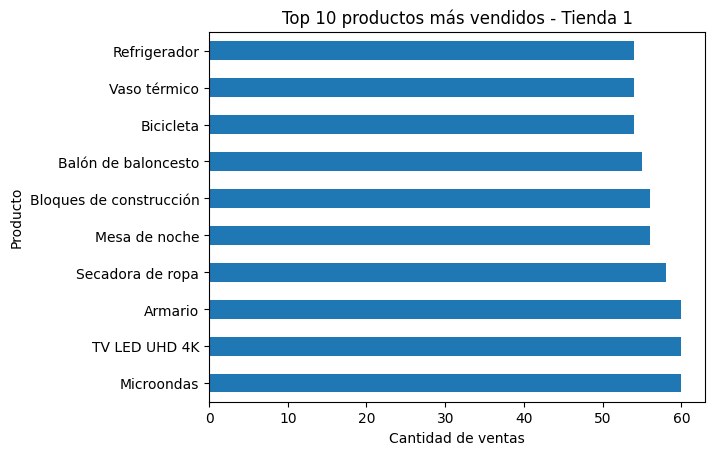

In [11]:
top_productos = tienda["Producto"].value_counts().head(10)

top_productos.plot(kind="barh")

plt.title("Top 10 productos más vendidos - Tienda 1")
plt.xlabel("Cantidad de ventas")

plt.show()

# Informe final del análisis de las tiendas de Alura Store



---

El objetivo de este análisis fue evaluar el desempeño de las cuatro tiendas de la cadena Alura Store para identificar cuál presenta el menor rendimiento. Para ello se analizaron diferentes métricas, como los ingresos totales, las categorías de productos más vendidas, las calificaciones promedio de los clientes, los productos más y menos vendidos y el costo promedio de envío.


## 1. Ingresos totales por tienda

A partir del análisis de la columna Precio, se calcularon los ingresos totales de cada tienda y de acuerdo a los resultados se observa que la tienda con menores ingresos es la Tienda 4, con un menor volumen de ventas en comparación con las demás de $1,038,375,700.0.

## 2. Categorías de productos más vendidas

El análisis de ventas por categoría mostró que las categorías más populares varían entre tiendas, pero en general destacan productos de **muebles y electrónicos**, con un total de:

*   Muebles      1,886 ventas
*   Electrónicos 1,772 ventas

Aunque las ventas son relativamente similares entre las tiendas, la Tienda 4 presenta menores resultados en algunas categorías clave, lo que puede contribuir a su menor ingreso total.

## 3. Calificación promedio de clientes

La satisfacción de los clientes es bastante similar entre todas las tiendas. La Tienda 3 presenta la mejor calificación promedio (4.05), seguida por la Tienda 2 (4.04) y la Tienda 4 (4.00).

La Tienda 1 presenta la calificación más baja (3.98), aunque la diferencia entre tiendas es mínima, por lo que este factor no parece tener un impacto significativo en el desempeño general

## 4. Productos más y menos vendidos

El análisis de productos permitió identificar los artículos con mayor y menor demanda.

*   Producto más vendido: Iniciando con programación
*   Producto menos vendido: Juegos de mesa

Estos resultados reflejan diferencias en la demanda de productos entre tiendas, aunque no muestran una concentración extrema de ventas en un solo tipo de producto.

## 5. Costo promedio de envío

Un costo de envío más alto  fue el de la tienda 1 con  $26,018.60, un costo de envío más alto puede influir en la decisión de compra de los clientes, aunque en este caso la Tienda 4 mantiene el costo más bajo sin que esto se traduzca en mayores ventas.
## 6. Conclusión y recomendación

Con base en los análisis realizados y en las métricas evaluadas, la Tienda 4 presenta el menor rendimiento general en comparación con las demás tiendas.

Esto se debe principalmente a que:

* Registra el menor ingreso total entre todas las tiendas.

* No destaca en volumen de ventas dentro de las principales categorías de productos.

* Aunque mantiene costos de envío competitivos y una buena calificación de clientes, estos factores no compensan su menor nivel de ventas.

Por estas razones, se recomienda que el Sr. Juan considere vender la Tienda 4 y destinar los recursos obtenidos a la apertura de un nuevo negocio o a fortalecer las tiendas con mejor desempeño dentro de la cadena.